### House Prices EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ml_pipeline.regression.pipeline import RegressionPipeline
from ml_pipeline.regression.config import regression_config as config

def boxplot(results: list, labels: list | None = None):
    data = []

    for item in results:
        data.append([x["score"] for x in item["fold_data"]])

    plt.boxplot(data, tick_labels=labels)
    plt.show()

Полный пайплайн

neg_root_mean_squared_error используется, потому что пайплайн выбирает наибольшую метрику, а не наименьшую (так как пайплайн изначально был построен под accuracy классификации)

In [ ]:
pipeline = RegressionPipeline()

In [ ]:
pipeline.run()

{'model': 'dummy'}
Шаг (0): dummy с {'strategy': 'mean'}
Фолд 1/5 neg_root_mean_squared_error: -0.4332
Фолд 2/5 neg_root_mean_squared_error: -0.3958
Фолд 3/5 neg_root_mean_squared_error: -0.3754
Фолд 4/5 neg_root_mean_squared_error: -0.4210
Фолд 5/5 neg_root_mean_squared_error: -0.3685
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.3988, std: 0.0251

{'model': 'linear', 'params': {'alpha': 1.0}}
Шаг (1): linear с {'alpha': 1.0, 'solver': 'auto', 'max_iter': 500}
Фолд 1/5 neg_root_mean_squared_error: -0.0935
Фолд 2/5 neg_root_mean_squared_error: -0.0924
Фолд 3/5 neg_root_mean_squared_error: -0.0861
Фолд 4/5 neg_root_mean_squared_error: -0.0860
Фолд 5/5 neg_root_mean_squared_error: -0.0793
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.0875, std: 0.0051

{'model': 'knn', 'params': {'n_neighbors': 3}}
Шаг (2): knn с {'n_neighbors': 3}
Фолд 1/5 neg_root_mean_squared_error: -0.0116
Фолд 2/5 neg_root_mean_squared_error: -0.0081
Фолд 3/5 neg_root_mean_squared_error: -0.0050
Фолд

ValueError: 'Sex' is not in list

### Линейная модель

#### Ridge

Посмотрим, как alpha l2 регуляризации влияет на метрику

Без alpha метрика улетает

Сабмит с базовым EDA, alpha=9:
* лучший фолд: 0.1155 (тут и дальше буду для удобства убирать знак минуса)
* public LB: 0.14020

Сабмит после логарифмирования некоторых фичей:
* лучший фолд: 0.1157
* public LB: 0.13790

In [2]:
config_alphas = config.copy()

to_train = []

for i in range(0, 10):
    to_train.append(
        {
            "model": "ridge",
            "params": {"alpha": i, "max_iter": 2000},
        }
    )

config_alphas.experiment.to_train = to_train
# config_alphas.experiment.prediction.fold_strategy = "vote"

linear_alphas_pipeline = RegressionPipeline(config_alphas)

linear_alphas_pipeline.run()

{'model': 'ridge', 'params': {'alpha': 0, 'max_iter': 2000}}
Шаг (0): ridge с {'alpha': 0, 'max_iter': 2000}
Фолд 1/5 neg_root_mean_squared_error: -492967804472.3296
Фолд 2/5 neg_root_mean_squared_error: -1325403290258.2642
Фолд 3/5 neg_root_mean_squared_error: -1105802215468.1050
Фолд 4/5 neg_root_mean_squared_error: -937282369588.8140
Фолд 5/5 neg_root_mean_squared_error: -1028585684943.2321
-> Лучший фолд: 1, CV neg_root_mean_squared_error: -978008272946.1490, std: 274406821950.3610

{'model': 'ridge', 'params': {'alpha': 1, 'max_iter': 2000}}
Шаг (1): ridge с {'alpha': 1, 'max_iter': 2000}
Фолд 1/5 neg_root_mean_squared_error: -0.1309
Фолд 2/5 neg_root_mean_squared_error: -0.1267
Фолд 3/5 neg_root_mean_squared_error: -0.2250
Фолд 4/5 neg_root_mean_squared_error: -0.1324
Фолд 5/5 neg_root_mean_squared_error: -0.1169
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.1464, std: 0.0397

{'model': 'ridge', 'params': {'alpha': 2, 'max_iter': 2000}}
Шаг (2): ridge с {'alpha': 2, 'max_

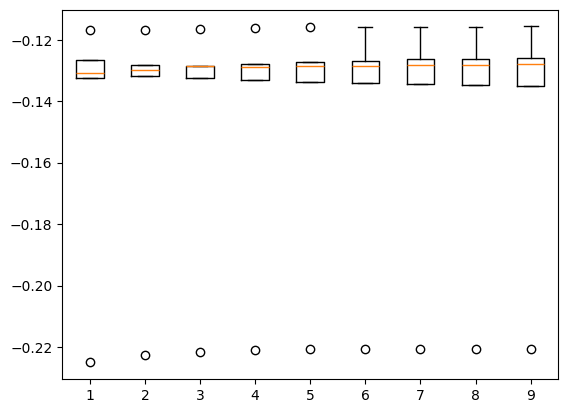

In [3]:
# не показывать результаты с alpha=0, чтобы не сбивать масштаб
boxplot(linear_alphas_pipeline.results[1:])

In [4]:
linear_alphas_pipeline.predict()

Лучший шаг: 9.ridge с {'alpha': 9, 'max_iter': 2000}
Предсказания сохранены в csv


#### Lasso

Применение Lasso здесь и ниже в ElasticNet не помогает

In [5]:
config_lasso = config.copy()

to_train = []

for i in range(0, 10):
    to_train.append(
        {
            "model": "lasso",
            "params": {"alpha": i, "max_iter": 2000},
        }
    )

config_lasso.experiment.to_train = to_train
# config_alphas.experiment.prediction.fold_strategy = "vote"

lasso_pipeline = RegressionPipeline(config_lasso)

lasso_pipeline.run()

{'model': 'lasso', 'params': {'alpha': 0, 'max_iter': 2000}}
Шаг (0): lasso с {'alpha': 0, 'max_iter': 2000}


x:\DSML\Miniconda\envs\titanic\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
x:\DSML\Miniconda\envs\titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
x:\DSML\Miniconda\envs\titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.781e+00, tolerance: 1.781e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_co

Фолд 1/5 neg_root_mean_squared_error: -0.1260


x:\DSML\Miniconda\envs\titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.966e+00, tolerance: 1.871e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
x:\DSML\Miniconda\envs\titanic\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
x:\DSML\Miniconda\envs\titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_co

Фолд 2/5 neg_root_mean_squared_error: -0.1226


...

Фолд 3/5 neg_root_mean_squared_error: -0.2218


x:\DSML\Miniconda\envs\titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.399e+00, tolerance: 1.811e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
x:\DSML\Miniconda\envs\titanic\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
x:\DSML\Miniconda\envs\titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_co

Фолд 4/5 neg_root_mean_squared_error: -0.1496


x:\DSML\Miniconda\envs\titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.151e+00, tolerance: 1.932e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


Фолд 5/5 neg_root_mean_squared_error: -0.1134
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.1467, std: 0.0394

{'model': 'lasso', 'params': {'alpha': 1, 'max_iter': 2000}}
Шаг (1): lasso с {'alpha': 1, 'max_iter': 2000}
Фолд 1/5 neg_root_mean_squared_error: -0.4332
Фолд 2/5 neg_root_mean_squared_error: -0.3958
Фолд 3/5 neg_root_mean_squared_error: -0.3754
Фолд 4/5 neg_root_mean_squared_error: -0.4210
Фолд 5/5 neg_root_mean_squared_error: -0.3685
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.3988, std: 0.0251

{'model': 'lasso', 'params': {'alpha': 2, 'max_iter': 2000}}
Шаг (2): lasso с {'alpha': 2, 'max_iter': 2000}
Фолд 1/5 neg_root_mean_squared_error: -0.4332
Фолд 2/5 neg_root_mean_squared_error: -0.3958
Фолд 3/5 neg_root_mean_squared_error: -0.3754
Фолд 4/5 neg_root_mean_squared_error: -0.4210
Фолд 5/5 neg_root_mean_squared_error: -0.3685
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.3988, std: 0.0251

{'model': 'lasso', 'params': {'alpha': 3, 'max_iter': 200

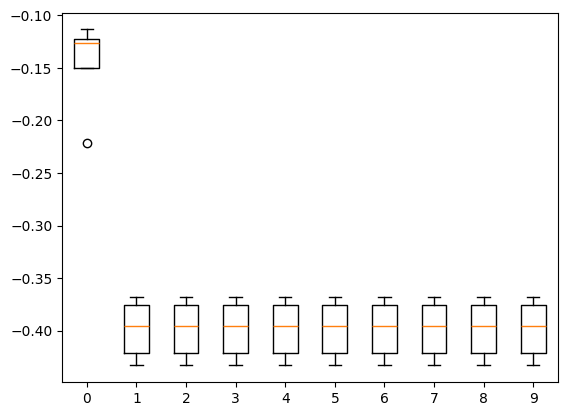

In [7]:
boxplot(lasso_pipeline.results, labels=[*range(0, 10)])

#### ElasticNet

Посмотрим разные комбинации коэффициентов регуляризации

Выглядит так, что L1 регуляризация только ухудшает модель?

In [8]:
config_elastic = config.copy()

to_train = []

ratios = [round(i * 0.1, 1) for i in range(0, 11)]

for i in ratios:
    to_train.append(
        {
            "model": "linear",
            "params": {"alpha": 1, "l1_ratio": i, "max_iter": 2000},
        }
    )

config_elastic.experiment.to_train = to_train
# config_alphas.experiment.prediction.fold_strategy = "vote"

el_pipeline = RegressionPipeline(config_elastic)

el_pipeline.run()

{'model': 'linear', 'params': {'alpha': 1, 'l1_ratio': 0.0, 'max_iter': 2000}}
Шаг (0): linear с {'alpha': 1, 'l1_ratio': 0.0, 'max_iter': 2000}


x:\DSML\Miniconda\envs\titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.165e+01, tolerance: 1.781e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


Фолд 1/5 neg_root_mean_squared_error: -0.1628


x:\DSML\Miniconda\envs\titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.271e+01, tolerance: 1.871e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


Фолд 2/5 neg_root_mean_squared_error: -0.1381


...

Фолд 3/5 neg_root_mean_squared_error: -0.2030


x:\DSML\Miniconda\envs\titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.195e+01, tolerance: 1.811e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


Фолд 4/5 neg_root_mean_squared_error: -0.1560


x:\DSML\Miniconda\envs\titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.306e+01, tolerance: 1.932e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


Фолд 5/5 neg_root_mean_squared_error: -0.1311
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.1582, std: 0.0252

{'model': 'linear', 'params': {'alpha': 1, 'l1_ratio': 0.1, 'max_iter': 2000}}
Шаг (1): linear с {'alpha': 1, 'l1_ratio': 0.1, 'max_iter': 2000}
Фолд 1/5 neg_root_mean_squared_error: -0.2714
Фолд 2/5 neg_root_mean_squared_error: -0.2336
Фолд 3/5 neg_root_mean_squared_error: -0.2353
Фолд 4/5 neg_root_mean_squared_error: -0.2646
Фолд 5/5 neg_root_mean_squared_error: -0.2209
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.2451, std: 0.0194

{'model': 'linear', 'params': {'alpha': 1, 'l1_ratio': 0.2, 'max_iter': 2000}}
Шаг (2): linear с {'alpha': 1, 'l1_ratio': 0.2, 'max_iter': 2000}
Фолд 1/5 neg_root_mean_squared_error: -0.3627
Фолд 2/5 neg_root_mean_squared_error: -0.3247
Фолд 3/5 neg_root_mean_squared_error: -0.3013
Фолд 4/5 neg_root_mean_squared_error: -0.3523
Фолд 5/5 neg_root_mean_squared_error: -0.3003
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.3283

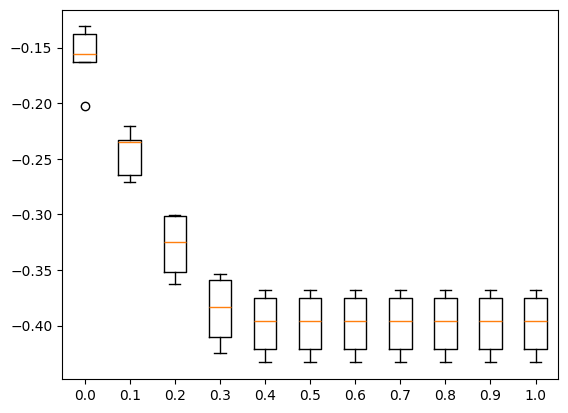

In [9]:
boxplot(el_pipeline.results, labels=ratios)

### KNN

Посмотрим, как меняется метрика в зависимости от количества соседей (k)

Возможно, метрические модели будут хуже работать из-за 'проклятия размерности'?

И в целом да, фолдов с метрикой лучше линейных не нашлось (возможно, стоит дропнуть некоторые фичи и посмотреть снова)

Для k=9
* лучший фолд: 0.1473
* public lb: 0.17047

In [11]:
config_knn = config.copy()

to_train = []

n_counts = [*range(1, 10), 15, 20, 25]

for i in n_counts:
    to_train.append(
        {
            "model": "knn",
            "params": {"n_neighbors": i},
        }
    )

config_knn.experiment.to_train = to_train

pipeline_knn = RegressionPipeline(config_knn)

pipeline_knn.run()

{'model': 'knn', 'params': {'n_neighbors': 1}}
Шаг (0): knn с {'n_neighbors': 1}
Фолд 1/5 neg_root_mean_squared_error: -0.1997
Фолд 2/5 neg_root_mean_squared_error: -0.2222
Фолд 3/5 neg_root_mean_squared_error: -0.2300
Фолд 4/5 neg_root_mean_squared_error: -0.2174
Фолд 5/5 neg_root_mean_squared_error: -0.2042
-> Лучший фолд: 1, CV neg_root_mean_squared_error: -0.2147, std: 0.0113

{'model': 'knn', 'params': {'n_neighbors': 2}}
Шаг (1): knn с {'n_neighbors': 2}
Фолд 1/5 neg_root_mean_squared_error: -0.1857
Фолд 2/5 neg_root_mean_squared_error: -0.2038
Фолд 3/5 neg_root_mean_squared_error: -0.1898
Фолд 4/5 neg_root_mean_squared_error: -0.2115
Фолд 5/5 neg_root_mean_squared_error: -0.1575
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.1896, std: 0.0186

{'model': 'knn', 'params': {'n_neighbors': 3}}
Шаг (2): knn с {'n_neighbors': 3}
Фолд 1/5 neg_root_mean_squared_error: -0.1891
Фолд 2/5 neg_root_mean_squared_error: -0.1916
Фолд 3/5 neg_root_mean_squared_error: -0.1819
Фолд 4/5 neg_

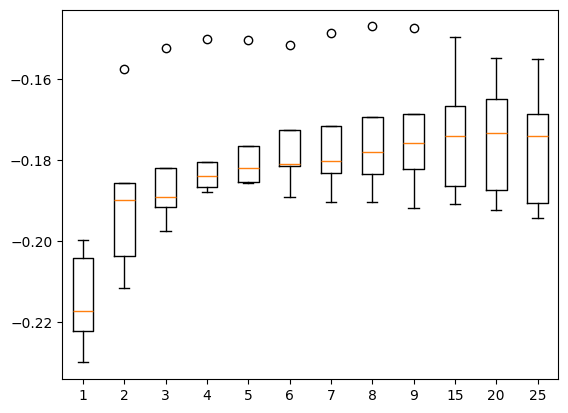

In [12]:
boxplot(pipeline_knn.results, labels=n_counts)

In [13]:
pipeline_knn.predict()

Лучший шаг: 8.knn с {'n_neighbors': 9}
Предсказания сохранены в csv


### Дерево

Лучший результат: мин. 5 объектов в листе
* лучший фолд: 0.1718
* lb: 0.19132

Наверное, одно дерево сильно переобучается для регрессии

In [14]:
config_tree = config.copy()

to_train = []

for i in range(1, 8):
    to_train.append(
        {
            "model": "decision_tree",
            "params": {"min_samples_leaf": i},
        }
    )

config_tree.experiment.to_train = to_train

pipeline_tree = RegressionPipeline(config_tree)

pipeline_tree.run()

{'model': 'decision_tree', 'params': {'min_samples_leaf': 1}}
Шаг (0): decision_tree с {'random_state': 42, 'min_samples_leaf': 1}
Фолд 1/5 neg_root_mean_squared_error: -0.1974
Фолд 2/5 neg_root_mean_squared_error: -0.2003
Фолд 3/5 neg_root_mean_squared_error: -0.2260
Фолд 4/5 neg_root_mean_squared_error: -0.1968
Фолд 5/5 neg_root_mean_squared_error: -0.2186
-> Лучший фолд: 4, CV neg_root_mean_squared_error: -0.2078, std: 0.0121

{'model': 'decision_tree', 'params': {'min_samples_leaf': 2}}
Шаг (1): decision_tree с {'random_state': 42, 'min_samples_leaf': 2}
Фолд 1/5 neg_root_mean_squared_error: -0.2024
Фолд 2/5 neg_root_mean_squared_error: -0.1935
Фолд 3/5 neg_root_mean_squared_error: -0.2329
Фолд 4/5 neg_root_mean_squared_error: -0.1876
Фолд 5/5 neg_root_mean_squared_error: -0.2071
-> Лучший фолд: 4, CV neg_root_mean_squared_error: -0.2047, std: 0.0157

{'model': 'decision_tree', 'params': {'min_samples_leaf': 3}}
Шаг (2): decision_tree с {'random_state': 42, 'min_samples_leaf': 3}
Ф

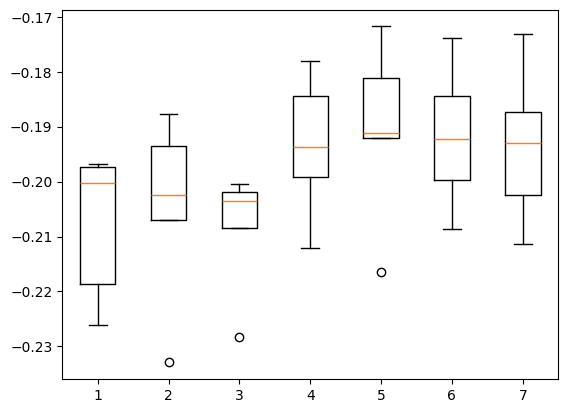

In [15]:
boxplot(pipeline_tree.results)

In [16]:
pipeline_tree.predict()

Лучший шаг: 4.decision_tree с {'min_samples_leaf': 5}
Предсказания сохранены в csv


### Случайный лес

После 300 деревьев глубиной 3 метрика уже не улучшается
* лучший фолд: 0.1752
* lb: 0.20153

Возможно, нужно изменить глубину дерева (см. ниже). Глубина 11, 300 деревьев:
* лучший фолд: 0.1223
* lb: 0.14560

In [18]:
config_rf = config.copy()

to_train = []

tree_counts = [*(i * 100 for i in range(1, 8)), 1000, 2000]

for i in tree_counts:
    to_train.append(
        {
            "model": "random_forest",
            "params": {"n_estimators": i},
        }
    )


config_rf.experiment.to_train = to_train

pipeline_rf = RegressionPipeline(config_rf)

pipeline_rf.run()

{'model': 'random_forest', 'params': {'n_estimators': 100}}
Шаг (0): random_forest с {'n_estimators': 100, 'max_depth': 3, 'random_state': 42}
Фолд 1/5 neg_root_mean_squared_error: -0.2067
Фолд 2/5 neg_root_mean_squared_error: -0.1817
Фолд 3/5 neg_root_mean_squared_error: -0.2077
Фолд 4/5 neg_root_mean_squared_error: -0.2188
Фолд 5/5 neg_root_mean_squared_error: -0.1752
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.1980, std: 0.0167

{'model': 'random_forest', 'params': {'n_estimators': 200}}
Шаг (1): random_forest с {'n_estimators': 200, 'max_depth': 3, 'random_state': 42}
Фолд 1/5 neg_root_mean_squared_error: -0.2063
Фолд 2/5 neg_root_mean_squared_error: -0.1812
Фолд 3/5 neg_root_mean_squared_error: -0.2066
Фолд 4/5 neg_root_mean_squared_error: -0.2180
Фолд 5/5 neg_root_mean_squared_error: -0.1756
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.1975, std: 0.0163

{'model': 'random_forest', 'params': {'n_estimators': 300}}
Шаг (2): random_forest с {'n_estimators': 300, '

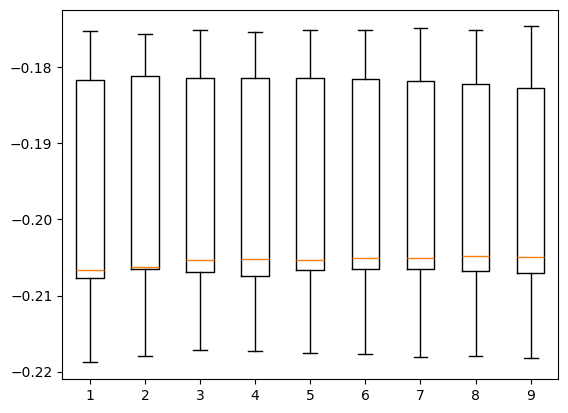

In [19]:
boxplot(pipeline_rf.results)

In [20]:
pipeline_rf.predict()

Лучший шаг: 2.random_forest с {'n_estimators': 300}
Предсказания сохранены в csv


Посмотрим на метрику в зависимости от глубины деревьев в лесу

In [4]:
config_rf_depth = config.copy()

to_train = []

tree_depths = [i for i in range(1, 13)]

for i in tree_depths:
    to_train.append(
        {
            "model": "random_forest",
            "params": {"n_estimators": 300, "max_depth": i },
        }
    )


config_rf_depth.experiment.to_train = to_train

pipeline_rfd = RegressionPipeline(config_rf_depth)

pipeline_rfd.run()

{'model': 'random_forest', 'params': {'n_estimators': 300, 'max_depth': 1}}
Шаг (0): random_forest с {'n_estimators': 300, 'max_depth': 1, 'random_state': 42}
Фолд 1/5 neg_root_mean_squared_error: -0.3073
Фолд 2/5 neg_root_mean_squared_error: -0.2901
Фолд 3/5 neg_root_mean_squared_error: -0.2839
Фолд 4/5 neg_root_mean_squared_error: -0.3125
Фолд 5/5 neg_root_mean_squared_error: -0.2734
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.2935, std: 0.0146

{'model': 'random_forest', 'params': {'n_estimators': 300, 'max_depth': 2}}
Шаг (1): random_forest с {'n_estimators': 300, 'max_depth': 2, 'random_state': 42}
Фолд 1/5 neg_root_mean_squared_error: -0.2491
Фолд 2/5 neg_root_mean_squared_error: -0.2213
Фолд 3/5 neg_root_mean_squared_error: -0.2372
Фолд 4/5 neg_root_mean_squared_error: -0.2547
Фолд 5/5 neg_root_mean_squared_error: -0.2079
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.2340, std: 0.0174

{'model': 'random_forest', 'params': {'n_estimators': 300, 'max_depth': 3}}


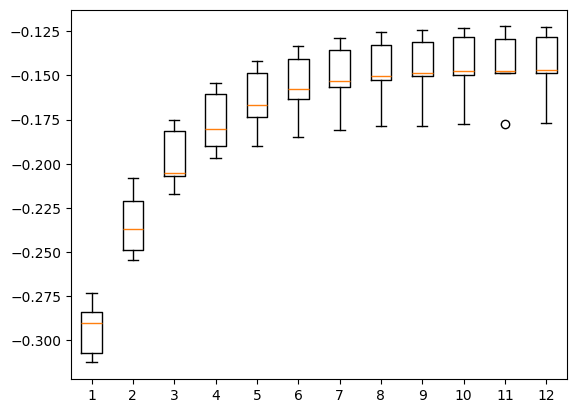

In [5]:
boxplot(pipeline_rfd.results)

In [6]:
pipeline_rfd.predict()

Лучший шаг: 11.random_forest с {'n_estimators': 300, 'max_depth': 12}
Предсказания сохранены в csv


### Бустинг

#### xgboost

С 700 деревьями:

* лучший фолд: 0.1142
* lb: 0.13901

In [21]:
config_xgb = config.copy()

to_train = []

n_estimators = [*[i * 100 for i in range(1, 8)], 1000, 2000]

for n in n_estimators:
    to_train.append(
        {
            "model": "xgboost",
            "params": {"n_estimators": n},
        }
    )

config_xgb.experiment.to_train = to_train

pipeline_xgb = RegressionPipeline(config_xgb)

pipeline_xgb.run()

{'model': 'xgboost', 'params': {'n_estimators': 100}}
Шаг (0): xgboost с {'n_estimators': 100, 'max_depth': 6, 'eval_metric': 'logloss', 'learning_rate': 0.1, 'random_state': 42}
Фолд 1/5 neg_root_mean_squared_error: -0.1447
Фолд 2/5 neg_root_mean_squared_error: -0.1319
Фолд 3/5 neg_root_mean_squared_error: -0.1747
Фолд 4/5 neg_root_mean_squared_error: -0.1390
Фолд 5/5 neg_root_mean_squared_error: -0.1159
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.1412, std: 0.0193

{'model': 'xgboost', 'params': {'n_estimators': 200}}
Шаг (1): xgboost с {'n_estimators': 200, 'max_depth': 6, 'eval_metric': 'logloss', 'learning_rate': 0.1, 'random_state': 42}
Фолд 1/5 neg_root_mean_squared_error: -0.1445
Фолд 2/5 neg_root_mean_squared_error: -0.1312
Фолд 3/5 neg_root_mean_squared_error: -0.1739
Фолд 4/5 neg_root_mean_squared_error: -0.1384
Фолд 5/5 neg_root_mean_squared_error: -0.1148
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.1406, std: 0.0194

{'model': 'xgboost', 'params': {'n_e

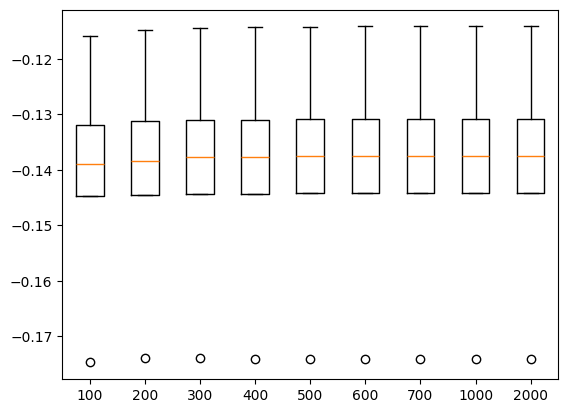

In [22]:
boxplot(pipeline_xgb.results, n_estimators)

In [23]:
pipeline_xgb.predict()

Лучший шаг: 6.xgboost с {'n_estimators': 700}
Предсказания сохранены в csv


#### CatBoost

для 100 деревьев
* лучший фолд: 0.1168
* lb: 0.13396

для 1000 деревьев
* лучший фолд: 0.1057
* lb: 0.12466

In [24]:
config_cat = config.copy()

to_train = []

iteration_counts = [*[i * 100 for i in range(1, 8)], 1000, 2000]

for ic in iteration_counts:
    to_train.append(
        {
            "model": "catboost",
            "params": {"iterations": ic},
        }
    )


config_cat.experiment.to_train = to_train

pipeline_cat = RegressionPipeline(config_cat)

pipeline_cat.run()

{'model': 'catboost', 'params': {'iterations': 100}}
Шаг (0): catboost с {'iterations': 100, 'depth': 6, 'cat_features': ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'], 'learning_rate': 0.1, 'random_state': 42, 'verbose': 0}
Фолд 1/5 neg_root_mean_squared_error: -0.1373
Фолд 2/5 neg_root_mean_squared_error: -0.1224
Фолд 3/5 neg_root_mean_squared_error: -0.1541
Фолд 4/5 neg_root_mean_squared_error: -0.1430
Фолд 5/5 neg_root_mean_squared_error: -0.1168
-> Лучший фо

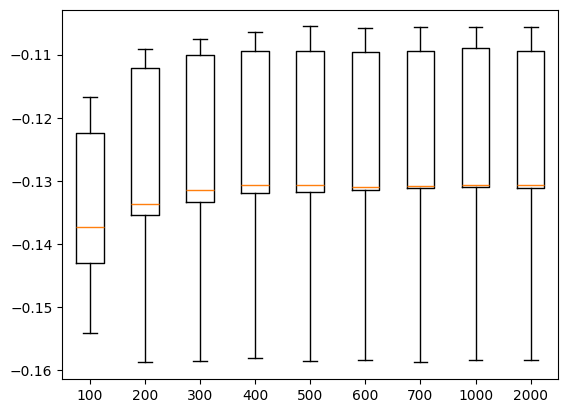

In [25]:
boxplot(pipeline_cat.results, iteration_counts)

In [7]:
config_cat_1k_trees = config.copy()

config_cat_1k_trees.experiment.to_train = [
    {
        "model": "catboost",
        "params": {"iterations": 1000},
    }
]

pipeline_cat_1k_trees = RegressionPipeline(config_cat_1k_trees)
pipeline_cat_1k_trees.run()

{'model': 'catboost', 'params': {'iterations': 1000}}
Шаг (0): catboost с {'iterations': 1000, 'depth': 6, 'cat_features': ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'], 'learning_rate': 0.1, 'random_state': 42, 'verbose': 0}
Фолд 1/5 neg_root_mean_squared_error: -0.1310
Фолд 2/5 neg_root_mean_squared_error: -0.1090
Фолд 3/5 neg_root_mean_squared_error: -0.1584
Фолд 4/5 neg_root_mean_squared_error: -0.1307
Фолд 5/5 neg_root_mean_squared_error: -0.1057
-> Лучший 

In [8]:
pipeline_cat_1k_trees.predict()

Лучший шаг: 0.catboost с {'iterations': 1000}
Предсказания сохранены в csv


### LightGBM

для 100 деревьев
* лучший фолд: 0.1122
* lb: 0.13041

In [6]:
config_l = config.copy()

to_train = []

n_estimators = [*[i * 100 for i in range(1, 8)], 1000, 2000]

for n in n_estimators:
    to_train.append(
        {
            "model": "lightgbm",
            "params": {"n_estimators": n},
        }
    )

config_l.experiment.to_train = to_train

config_l.split.n_folds = 5

pipeline_l = RegressionPipeline(config_l)

pipeline_l.run()

{'model': 'lightgbm', 'params': {'n_estimators': 100}}
Шаг (0): lightgbm с {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'random_state': 42, 'verbose': -1}
Фолд 1/5 neg_root_mean_squared_error: -0.1386
Фолд 2/5 neg_root_mean_squared_error: -0.1177
Фолд 3/5 neg_root_mean_squared_error: -0.1683
Фолд 4/5 neg_root_mean_squared_error: -0.1331
Фолд 5/5 neg_root_mean_squared_error: -0.1122
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.1340, std: 0.0197

{'model': 'lightgbm', 'params': {'n_estimators': 200}}
Шаг (1): lightgbm с {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'random_state': 42, 'verbose': -1}
Фолд 1/5 neg_root_mean_squared_error: -0.1408
Фолд 2/5 neg_root_mean_squared_error: -0.1181
Фолд 3/5 neg_root_mean_squared_error: -0.1684
Фолд 4/5 neg_root_mean_squared_error: -0.1329
Фолд 5/5 neg_root_mean_squared_error: -0.1115
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.1343, std: 0.0199

{'model': 'lightgbm', 'params': {'n_estimators': 300}}

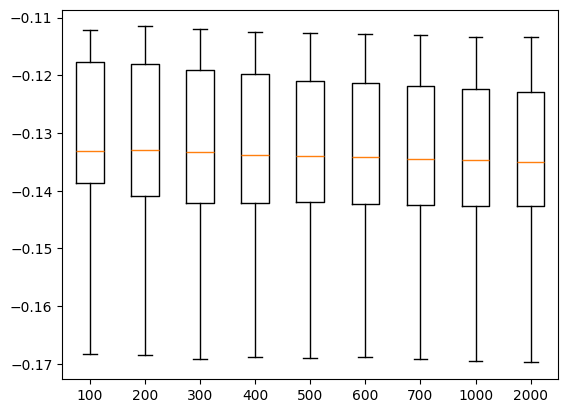

In [7]:
boxplot(pipeline_l.results, n_estimators)

In [8]:
pipeline_l.predict()

Лучший шаг: 0.lightgbm с {'n_estimators': 100}
Series([], dtype: int64)
Предсказания сохранены в csv
